In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model='gpt-4o-mini')

In [5]:
class LLMState(TypedDict):
    
    question: str
    answer: str

In [6]:
def LLM_qa(state: LLMState) -> LLMState:
    
    question = state['question']
    
    prompt = f'Answer the following question {question}'
    
    answer = model.invoke(prompt).content
    
    state['answer'] = answer
    
    return state

In [10]:
graph = StateGraph(LLMState)

graph.add_node('LLM_qa', LLM_qa)

graph.add_edge(START, 'LLM_qa')
graph.add_edge('LLM_qa',END)

workflow = graph.compile()

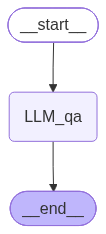

In [ ]:
initial_state = {'question':"How far is the Moon from the Earth?"}

final_state = workflow.invoke(initial_state)

In [12]:
final_state

{'question': 'How far is the Moon from the Earth?',
 'answer': "The average distance from the Earth to the Moon is about 238,855 miles (384,400 kilometers). However, this distance can vary slightly due to the Moon's elliptical orbit around the Earth."}